# Sentinel-3 OLCI L1 EFR → GeoZarr

This notebook demonstrates the Sentinel-3 OLCI exporter in `eopf-geozarr`:

1. **Open** an EOPF Zarr Sentinel-3 OLCI L1 EFR product.
2. **Detect** that it is an OLCI product.
3. **Convert** it to a GeoZarr-compliant, multiscale Zarr store.
4. **Visualize** the multiscale pyramid by drawing each quadrant of the swath
   from a **different overview level** — each on its own native
   latitude/longitude grid, no resampling — over a coastline map.

OLCI is delivered as a **curvilinear swath** (per-pixel 2-D latitude/longitude,
no projected CRS). The exporter preserves that native geometry — it does not
reproject. Radiance overviews are fill-aware 2×2 block means, and each
overview's latitude/longitude are the **geodesic centroids** of the same
pixel blocks (a unit-vector mean on the sphere, stable across the
antimeridian), so every overview cell is geolocated at the center of the
pixels it averages.

> Requires the `notebooks` dependency group:
> `uv sync --group notebooks` (jupyter, matplotlib, cartopy, nbformat).

In [1]:
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr

from eopf_geozarr.s3_olci_optimization.olci_converter import (
    convert_olci_optimized,
    is_sentinel3_olci_dataset,
)
from eopf_geozarr.conversion.geozarr import get_zarr_group

## 1. Open an EOPF OLCI product

We open a real Sentinel-3 OLCI L1 EFR product from the EOPF sample store on
EODC. If the store is unreachable (offline / CI), we fall back to the small
structure-only test fixture shipped with the repository so the notebook still
runs end to end.

EOPF radiance is stored as scaled `uint16`; we open with `mask_and_scale=False`
so the raw integers and their `scale_factor` / `_FillValue` are preserved for a
faithful conversion (the converter expects un-decoded input).

In [2]:
# A real OLCI L1 EFR product on the EODC EOPF sample store (use an _NT_,
# fully-consolidated product — _NR_ near-real-time copies may lack metadata).
EODC_OLCI_URL = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:202511-s03olcefr-eu/"
    "01/products/cpm_v262/"
    "S3A_OL_1_EFR____20251101T073957_20251101T074257_20251102T084255_"
    "0179_132_149_2160_PS1_O_NT_004.zarr"
)


def open_olci_input() -> xr.DataTree:
    """Open the remote OLCI product; fall back to the repo test fixture offline."""
    try:
        dt = xr.open_datatree(
            EODC_OLCI_URL, engine="zarr", chunks={}, mask_and_scale=False
        )
        print("Opened remote EODC OLCI product.")
        return dt
    except Exception as exc:  # noqa: BLE001 - notebook offline fallback
        print(f"Remote open failed ({type(exc).__name__}); using bundled fixture.")
        import sys

        # Resolve the repo root regardless of the kernel's working directory
        # (interactive runs start in docs/notebooks/, CI may start at the root).
        repo_root = next(
            p
            for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
            if (p / "tests" / "_test_data").exists()
        )
        if str(repo_root) not in sys.path:
            sys.path.insert(0, str(repo_root))
        from tests.conftest import create_group_from_json

        fixture = repo_root / (
            "tests/_test_data/s3_examples/"
            "S3A_OL_1_EFR____20251101T073957_20251101T074257_20251102T084255_"
            "0179_132_149_2160_PS1_O_NT_004.json"
        )
        store = create_group_from_json(fixture, pathlib.Path(tempfile.mkdtemp()))
        return xr.open_datatree(store, engine="zarr", mask_and_scale=False)


dt_input = open_olci_input()
print("Top-level groups:", sorted(dt_input.groups))

Opened remote EODC OLCI product.
Top-level groups: ['/', '/conditions', '/conditions/geometry', '/conditions/image', '/conditions/instrument', '/conditions/meteorology', '/conditions/orphans', '/measurements', '/measurements/orphans', '/quality', '/quality/orphans']


### Inspect the measurements group

OLCI L1 EFR carries 21 radiance bands (`oa01_radiance` … `oa21_radiance`) on a
single full-resolution grid, geolocated by per-pixel 2-D `latitude` /
`longitude` coordinate arrays.

In [3]:
meas = dt_input["/measurements"].to_dataset()
bands = [v for v in meas.data_vars if str(v).endswith("_radiance")]
print(f"{len(bands)} radiance bands; e.g. {bands[:3]} … {bands[-1]}")
oa = meas["oa01_radiance"]
print("oa01_radiance:", oa.shape, oa.dtype, "| dims", oa.dims)
print("scale_factor:", oa.attrs.get("scale_factor"), "| _FillValue:", oa.attrs.get("_FillValue"))
print("geolocation coords:", [c for c in ("latitude", "longitude", "altitude") if c in meas])

21 radiance bands; e.g. ['oa01_radiance', 'oa02_radiance', 'oa03_radiance'] … oa21_radiance
oa01_radiance: (4090, 4865) uint16 | dims ('rows', 'columns')
scale_factor: 0.013946459628641605 | _FillValue: 65535
geolocation coords: ['latitude', 'longitude', 'altitude']


## 2. Detect the product type

Detection is structural: a product is OLCI iff it validates against the OLCI
data model and its measurements group contains the radiance bands.

In [4]:
group = get_zarr_group(dt_input)
print("is_sentinel3_olci_dataset:", is_sentinel3_olci_dataset(group))

is_sentinel3_olci_dataset: True


## 3. Convert to GeoZarr

`convert_olci_optimized` writes the native measurements group plus `/2`
block-averaged overview subgroups (`r2`, `r4`, …) down to `min_dimension`, and
declares them with the GeoZarr `multiscales` convention. `conditions` and
`quality` are copied through unchanged.

We use a small `min_dimension` here so even the small sample yields several
overview levels to visualize.

In [5]:
output_path = str(pathlib.Path(tempfile.mkdtemp()) / "olci_geozarr.zarr")
convert_olci_optimized(dt_input, output_path=output_path, min_dimension=4)

store = zarr.open_group(output_path, mode="r")
# Overview levels are the rN subgroups under measurements (exclude e.g. orphans).
levels = ["."] + sorted(
    (k for k in store["measurements"].group_keys() if k.startswith("r")),
    key=lambda k: int(k[1:]),
)
print("Pyramid levels (native + overviews):", levels)

2026-07-09 07:35:36 [info     ] Writing native-resolution measurements shape={'rows': 4090, 'columns': 4865}


2026-07-09 07:35:57 [info     ] Generating overview levels     n_levels=9


2026-07-09 07:37:05 [info     ] Writing overview               group=measurements/r2 shape={'rows': 2045, 'columns': 2432}


2026-07-09 07:37:09 [info     ] Writing overview               group=measurements/r4 shape={'rows': 1022, 'columns': 1216}


2026-07-09 07:37:11 [info     ] Writing overview               group=measurements/r8 shape={'rows': 511, 'columns': 608}


...

2026-07-09 07:37:25 [info     ] Copying ancillary subgroup     group=quality


2026-07-09 07:37:34 [info     ] Copying ancillary subgroup     group=quality/orphans


2026-07-09 07:37:35 [info     ] Copying measurements subgroup  group=measurements/orphans


2026-07-09 07:37:35 [info     ] Copying ancillary subgroup     group=measurements/orphans


Pyramid levels (native + overviews): ['.', 'r2', 'r4', 'r8', 'r16', 'r32', 'r64', 'r128', 'r256', 'r512']


### Load every pyramid level

Level `.` is the native resolution written at the measurements group root;
`r2`, `r4`, … are successively coarser block-averaged overviews. Each level is
opened as a Dataset so we get the radiance band **together with that level's
own `latitude`/`longitude` coordinates** (the geodesic centroids of that
level's pixel blocks). We read with default decoding so the stored `uint16`
radiance is scaled to physical units (and fill pixels become NaN) for display.

In [6]:
BAND = "oa08_radiance"  # ~665 nm (red); good visual contrast


def read_level(level: str) -> xr.Dataset:
    """Open one pyramid level as a Dataset (band + its own lat/lon)."""
    group = "measurements" if level == "." else f"measurements/{level}"
    return xr.open_dataset(output_path, engine="zarr", group=group, consolidated=False)


level_datasets = {lvl: read_level(lvl) for lvl in levels}
for lvl, ds in level_datasets.items():
    print(f"{lvl:>4}: shape {tuple(ds[BAND].shape)}")

   .: shape (4090, 4865)
  r2: shape (2045, 2432)
  r4: shape (1022, 1216)
  r8: shape (511, 608)
 r16: shape (255, 304)
 r32: shape (127, 152)
 r64: shape (63, 76)
r128: shape (31, 38)
r256: shape (15, 19)
r512: shape (7, 9)


## 4. One swath, four resolutions, over a map

The map below splits the swath into four geographic quadrants and draws each
quadrant from a **different pyramid level**, using xarray's curvilinear
plotting (`DataArray.plot.pcolormesh(x="longitude", y="latitude")`) on a
cartopy `PlateCarree` map. Each quadrant is that level's stored arrays,
exactly as written — radiance against its own centroid latitude/longitude —
so the quadrants tile the swath seamlessly while the visible cell size grows
4× (2× per axis) from one quadrant to the next.

The finest levels (native, `r2`, `r4`) are stored identically but skipped
here only because `pcolormesh` with millions of quads is slow to render; we
pick four levels spanning the affordable range down to the coarsest.

Quadrant levels (finest → coarsest): ['r8', 'r32', 'r128', 'r512']


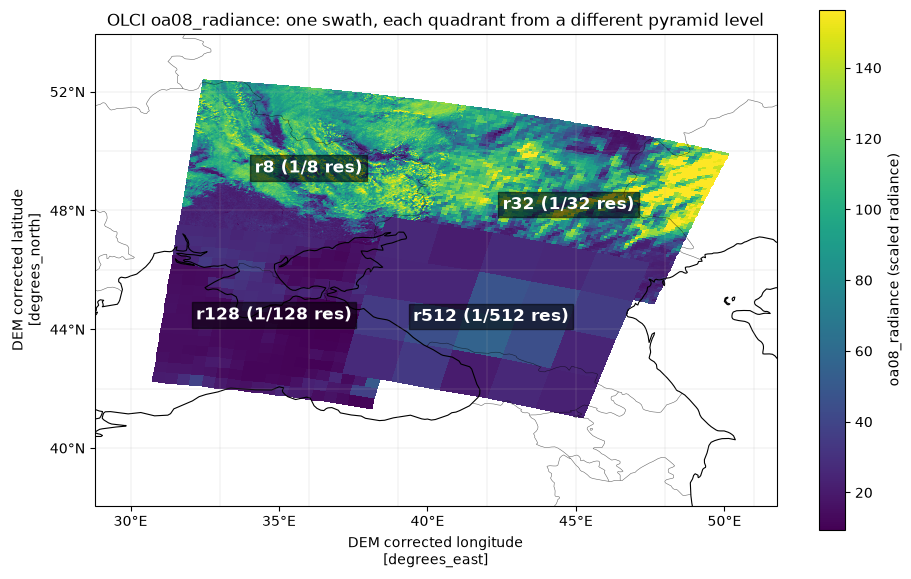

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

# Pick four levels: the finest that is still cheap to draw as quads, through
# the coarsest available (deduplicated for small fixture inputs).
MAX_CELLS = 600_000
candidates = [lvl for lvl in levels if level_datasets[lvl][BAND].size <= MAX_CELLS]
pick = sorted(set(np.linspace(0, len(candidates) - 1, 4).round().astype(int)))
quad_levels = [candidates[i] for i in pick]
print("Quadrant levels (finest → coarsest):", quad_levels)

# Robust shared color scale from the finest level shown.
finest = level_datasets[quad_levels[0]][BAND]
vmin, vmax = (float(v) for v in finest.quantile([0.02, 0.98]))

# Map extent from the finest level's coordinates, with a margin.
pad = 1.5
extent = [
    float(level_datasets[quad_levels[0]]["longitude"].min()) - pad,
    float(level_datasets[quad_levels[0]]["longitude"].max()) + pad,
    float(level_datasets[quad_levels[0]]["latitude"].min()) - pad,
    float(level_datasets[quad_levels[0]]["latitude"].max()) + pad,
]

fig = plt.figure(figsize=(11, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# One level per swath quadrant (row half × column half of the pixel grid).
quadrants = [(0, 0), (0, 1), (1, 0), (1, 1)]
for lvl, (row_half, col_half) in zip(quad_levels, quadrants):
    band = level_datasets[lvl][BAND]
    nr, nc = band.sizes["rows"], band.sizes["columns"]
    piece = band.isel(
        rows=slice(0, nr // 2) if row_half == 0 else slice(nr // 2, None),
        columns=slice(0, nc // 2) if col_half == 0 else slice(nc // 2, None),
    )
    # xarray draws the curvilinear quads straight from the level's own
    # 2-D centroid coordinates — nothing is resampled.
    mesh = piece.plot.pcolormesh(
        x="longitude",
        y="latitude",
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        shading="nearest",
        add_colorbar=False,
        rasterized=True,
    )
    res = 1 if lvl == "." else int(lvl[1:])
    ax.text(
        float(piece["longitude"].mean()),
        float(piece["latitude"].mean()),
        f"{lvl} (1/{res} res)",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white",
        bbox={"facecolor": "black", "alpha": 0.55, "pad": 3},
    )

ax.coastlines(resolution="50m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.6)
# Label lat/lon with explicit ticks: cartopy's gridline auto-labels
# (draw_labels=True) blank the GeoAxes when a colorbar is added
# (cartopy 0.25 / matplotlib 3.11 incompatibility).
ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
ax.set_xticks(np.arange(np.ceil(extent[0] / 5) * 5, extent[1], 5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(np.ceil(extent[2] / 4) * 4, extent[3], 4), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
fig.colorbar(mesh, ax=ax, shrink=0.75, label=f"{BAND} (scaled radiance)")
ax.set_title(f"OLCI {BAND}: one swath, each quadrant from a different pyramid level")
plt.show()

The four quadrants tile the swath with no gaps or seams even though each is
drawn from a different stored array on a different grid: the levels agree on
*where* things are because every overview cell's latitude/longitude is the
geodesic centroid of the pixel block it averages. The blockiness that grows
from quadrant to quadrant is each level's true native resolution — the
multiscale pyramid itself, placed on the map without any resampling.